In [21]:
%load_ext autoreload
%autoreload 2
import torch
import torchvision
import numpy as np
from tqdm import tqdm
from TextToConcept import TextToConcept
import my_utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [23]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
from transformers import VideoMAEModel
from video_utils import VideoMAETTCTWrapper

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# feature_extractor = VideoMAEVideoProcessor.from_pretrained("MCG-NJU/videomae-small-finetuned-ssv2")  # TODO unnecessary??
videomae_model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
videomae_model = videomae_model.to(device)

model = VideoMAETTCTWrapper(videomae_model, normalizer=torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 7698.73it/s]
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.norm.weight                                                  | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  

In [25]:
# text_to_concept = TextToConcept(model, model_name='resnet50', input_type='video')
text_to_concept = TextToConcept(model, model_name='videomae', input_type='video')

In [26]:
path = 'pretrained_aligners/videomae_base_aligner_k400.pth'
text_to_concept.load_linear_aligner(path, device='cpu')
text_to_concept.device = torch.device('cpu')

In [27]:
# dset_name = 'ssv2_val'
dset_name = 'k400_train'

In [40]:
import json
from pathlib import Path
from video_utils import load_ssv2_split, DivideBy255, CTHWToTCHW, ToTensorTuple
from train_video_aligner import SizedLabeledVideoDataset
from video_utils import load_k400_split
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler


def filter_labeled_video_paths_by_labels(labeled_video_paths, allowed_labels, class_to_idx=None):
    if class_to_idx is not None:
        allowed_labels = {
            class_to_idx[label] if isinstance(label, str) else int(label)
            for label in allowed_labels
        }
    else:
        allowed_labels = {int(label) for label in allowed_labels}

    filtered_vids = [
        (video_path, info)
        for video_path, info in labeled_video_paths
        if info["label"] in allowed_labels
    ]
    new_class_to_index = {label: idx for idx, label in enumerate(sorted(allowed_labels))}

    return filtered_vids, new_class_to_index


preprocessing_without_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

K400_ROOT = Path("dataset/k400")
K400_CLASSES_PATH = Path("dataset/k400/kinetics_classnames.json")

CLASSES_TO_KEEP = [
    "bowling",
    "chopping wood",
    "playing guitar",
    "playing piano",
    "riding a bike",
    "swimming backstroke",
]

with open(K400_CLASSES_PATH, 'r') as f:
    class_to_idx = json.load(f)
class_to_idx = {k.strip('"'): int(v) for k, v in class_to_idx.items()}

labeled_video_paths = load_k400_split(
    "train",
    K400_ROOT / "train/1",
    class_to_idx=class_to_idx
)

clip_sampler = UniformClipSampler(clip_duration=3.0)

subset_paths, map_old_to_new_index = filter_labeled_video_paths_by_labels(
    labeled_video_paths,
    allowed_labels=CLASSES_TO_KEEP,
    class_to_idx=class_to_idx
)

subset_class_names = [None] * len(map_old_to_new_index)
for class_name, old_idx in class_to_idx.items():
    if old_idx in map_old_to_new_index:
        subset_class_names[map_old_to_new_index[old_idx]] = class_name

dset = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

print(len(dset))
print(subset_class_names)


200
['bowling', 'chopping wood', 'playing guitar', 'playing piano', 'riding a bike', 'swimming backstroke']


# Load concept scores

In [41]:
# templates = ['itap of a {}', 'a bad photo of the {}', 'a origami {}', 'a photo of the large {}',
#              'a {} in a video game', 'art of the {}', 'a photo of the small {}']
templates = [
    'a video of someone {}',
    'a bad video of someone {}',
    'a video of someone clearly {}',
    'someone {} in a video',
]  # TODO prompt engineering


# Train CBM

In [42]:
text_to_concept.device = torch.device('mps')

In [43]:
text_to_concept.clip_model = text_to_concept.clip_model.to('mps')

In [44]:
import pandas as pd
from concept_bottleneck_model import ConceptBottleneckModel, CBMTrainer

concept_df = pd.read_csv('concept_prompts_viclip.csv')
concept_list = list(concept_df['prompt'])

mtype = 'videomae'
cbm = ConceptBottleneckModel(concept_list, subset_class_names, mtype)
trainer = CBMTrainer(cbm)
_ = cbm.embed_concepts(text_to_concept.clip_model.to('cpu').eval())

In [46]:
from pathlib import Path
import numpy as np
import torch

vision_names = np.load('data/reps_videomae_k400__working/representations_k400vision_model_reps_names.npy')
vision_reps = np.load('data/reps_videomae_k400__working/representations_k400vision_model_reps.npy')

name_to_label = {
    Path(video_path).stem: map_old_to_new_index[info["label"]]
    for video_path, info in dset._labeled_videos
}

matched_idx = np.array([
    i for i, name in enumerate(vision_names)
    if Path(str(name)).stem in name_to_label
])

subset_vision_names = vision_names[matched_idx]
subset_vision_reps = vision_reps[matched_idx]
labels = np.array(
    [name_to_label[Path(str(name)).stem] for name in subset_vision_names],
    dtype=np.int64,
)

aligned_subset_vision_reps = (
    text_to_concept.linear_aligner
    .get_aligned_representation(torch.from_numpy(subset_vision_reps).float().to('cpu'))
    .detach()
    .cpu()
    .numpy()
)

sims = cbm.get_concept_concept_scores(aligned_subset_vision_reps)

print(f"matched {len(subset_vision_names)} / {len(vision_names)} saved reps")
print(subset_vision_reps.shape, aligned_subset_vision_reps.shape, labels.shape)

matched 514 / 30660 saved reps
(514, 768) (514, 768) (514,)


/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: divide by zero encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: overflow encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: invalid value encountered in matmul
  scores = vision_features @ concept_embeddings.T


In [47]:
# from pathlib import Path

# name_to_label = {
#     Path(video_path).stem: map_old_to_new_index[info["label"]]
#     for video_path, info in dset._labeled_videos
# }

# labels = np.array([name_to_label[Path(name).stem.strip('.mp4')] for name in subset_vision_names])

In [49]:
torch.manual_seed(42)
np.random.seed(42)
trainer.train(concept_scores=sims, labels=labels, batch_size=8, epochs=100)

Training concept bottleneck ...
Linear projection: (89) --> (6).
Initial loss: 1.810
Epoch number, loss: 0, 1.770
Full-batch loss: 1.734
Epoch number, loss: 1, 1.721
Full-batch loss: 1.710
Epoch number, loss: 2, 1.703
Full-batch loss: 1.695
Epoch number, loss: 3, 1.688
Full-batch loss: 1.682
Epoch number, loss: 4, 1.675
Full-batch loss: 1.670
Epoch number, loss: 5, 1.675
Full-batch loss: 1.658
Epoch number, loss: 6, 1.653
Full-batch loss: 1.646
Epoch number, loss: 7, 1.640
Full-batch loss: 1.635
Epoch number, loss: 8, 1.643
Full-batch loss: 1.624
Epoch number, loss: 9, 1.619
Full-batch loss: 1.613
Epoch number, loss: 10, 1.607
Full-batch loss: 1.603
Epoch number, loss: 11, 1.598
Full-batch loss: 1.592
Epoch number, loss: 12, 1.595
Full-batch loss: 1.582
Epoch number, loss: 13, 1.585
Full-batch loss: 1.572
Epoch number, loss: 14, 1.567
Full-batch loss: 1.563
Epoch number, loss: 15, 1.560
Full-batch loss: 1.553
Epoch number, loss: 16, 1.552
Full-batch loss: 1.544
Epoch number, loss: 17, 

In [48]:
# torch.save(trainer.cbm_model.bottleneck, 'pretrained_aligners/videomae_base_cbm_bottleneck_k400.pth')
trainer.cbm_model.bottleneck = torch.load('pretrained_aligners/videomae_base_cbm_bottleneck_k400.pth')

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch.nn.modules.linear.Linear was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch.nn.modules.linear.Linear])` or the `torch.serialization.safe_globals([torch.nn.modules.linear.Linear])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to lea

class: swimming backstroke
chosen idx: 412
video stem: BC0CHSppjhA
video path: dataset/k400/train/1/swimming backstroke/BC0CHSppjhA.mp4

Top concept scores:
a video of fast-paced action                  0.194
a video taken high above the ground           0.191
a video of downward movement                  0.191
a video of upward movement                    0.191
a video of a person doing a leisure activity  0.181
a video of slow deliberate movement           0.181
a video of people competing in a sport        0.179
a video of sideways movement                  0.173
a video of motion shaped by air resistance or aerodynamic movement 0.167
a video in a natural landscape                0.165

Class probabilities:
swimming backstroke  0.683
chopping wood        0.156
bowling              0.069
riding a bike        0.057
playing piano        0.019
playing guitar       0.017


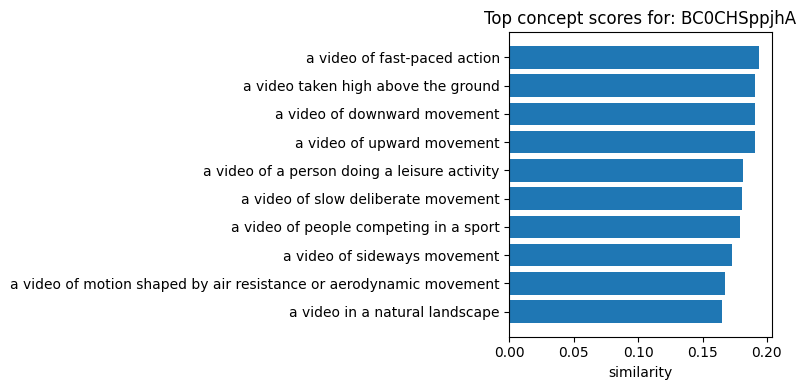

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


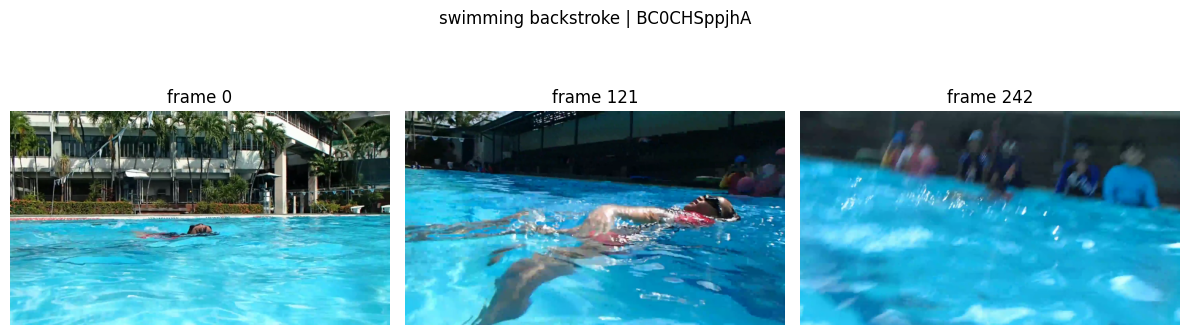

In [50]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

# TARGET_CLASS = "bowling"  # ish
# TARGET_CLASS = "chopping wood"  # ish
# TARGET_CLASS = "playing guitar"  # proper
# TARGET_CLASS = "playing piano"  # ish
# TARGET_CLASS = "riding a bike"  # bad
TARGET_CLASS = "swimming backstroke"  # GOOD
N_TOP_CONCEPTS = 10
N_FRAMES = 3
SEED = 42

rng = np.random.default_rng(SEED)

# Map class name -> class index
class_idx = subset_class_names.index(TARGET_CLASS)

# Pick one random matched example from that class
candidate_idx = np.where(labels == class_idx)[0]
chosen_idx = int(rng.choice(candidate_idx))

chosen_name = Path(str(subset_vision_names[chosen_idx])).stem
path_by_stem = {Path(video_path).stem: video_path for video_path, _ in dset._labeled_videos}
video_path = path_by_stem[chosen_name]

print("class:", TARGET_CLASS)
print("chosen idx:", chosen_idx)
print("video stem:", chosen_name)
print("video path:", video_path)

# Concept scores for this example
concept_scores = sims[chosen_idx]
top_idx = np.argsort(-concept_scores)[:N_TOP_CONCEPTS]

print("\nTop concept scores:")
for i in top_idx:
    print(f"{concept_list[i]:45s} {concept_scores[i]:.3f}")

# Optional: class probabilities from trained CBM
with torch.no_grad():
    x = torch.from_numpy(sims[chosen_idx:chosen_idx+1]).float().to(trainer.device)
    logits = trainer.model(x)
    probs = logits.softmax(dim=1).cpu().numpy()[0]

print("\nClass probabilities:")
for i in np.argsort(-probs):
    print(f"{subset_class_names[i]:20s} {probs[i]:.3f}")

# Plot top concept scores
plt.figure(figsize=(8, 4))
plt.barh([concept_list[i] for i in top_idx][::-1], concept_scores[top_idx][::-1])
plt.title(f"Top concept scores for: {chosen_name}")
plt.xlabel("similarity")
plt.tight_layout()
plt.show()

# Load full video and show evenly spaced frames
frames, _, info = torchvision.io.read_video(video_path, pts_unit="sec")
num_frames = len(frames)

frame_idx = np.linspace(0, num_frames - 1, N_FRAMES, dtype=int)

fig, axes = plt.subplots(1, N_FRAMES, figsize=(4 * N_FRAMES, 4))
if N_FRAMES == 1:
    axes = [axes]

for ax, fi in zip(axes, frame_idx):
    ax.imshow(frames[fi].numpy())
    ax.set_title(f"frame {fi}")
    ax.axis("off")

plt.suptitle(f"{TARGET_CLASS} | {chosen_name}")
plt.tight_layout()
plt.show()


### Test

In [61]:
import json
from pathlib import Path
from video_utils import load_ssv2_split, DivideBy255, CTHWToTCHW, ToTensorTuple
from train_video_aligner import SizedLabeledVideoDataset
from video_utils import load_k400_split
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler

preprocessing_without_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

K400_ROOT = Path("dataset/k400")
K400_CLASSES_PATH = Path("dataset/k400/kinetics_classnames.json")

with open(K400_CLASSES_PATH, 'r') as f:
    class_to_idx = json.load(f)
class_to_idx = {k.strip('"'): int(v) for k, v in class_to_idx.items()}

labeled_video_paths = load_k400_split(
    "test",
    K400_ROOT / "test/1/videos_val",
    class_to_idx=class_to_idx,
    labels_path=Path(K400_ROOT / "test/1/kinetics400_val_list_videos.txt")
)
# labeled_video_paths = load_k400_split(
#     "train",
#     K400_ROOT / "train/1",
#     class_to_idx=class_to_idx
# )

subset_paths_test, test_old_to_new_index = filter_labeled_video_paths_by_labels(
    labeled_video_paths,
    allowed_labels=CLASSES_TO_KEEP,
    class_to_idx=class_to_idx
)

dset_test = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths_test,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

print(len(dset_test))
print(test_old_to_new_index == map_old_to_new_index)


296
True


In [71]:
test_vision_names[0]

np.str_('-WKCwDRp_jk')

In [73]:
test_name_to_label.keys()

dict_keys(['S6iAYBBMnwk', 'B3qb2F_MxRw', 'Hz0E5D4P7gI', 'mE4-cdQxdgM', 'o018kcJ4CqU', 'Z3XphEQB8XU', 'Kv6Lgh1DRF8', 'yKjJHObLUws', '1z2BaaWe-Hc', 'daYtZ0t1ACk', 'AxKiC7Soc6s', 'Ua_8t0VNszU', 'GAw4NZDPCuU', 'S8sXdqGwrAg', 's3dK8R-jzac', 'ZLCntgQ9KHc', 'gdeAg8y3v_g', 'xxrNO_Q4LcE', 'Ot3j0CHnWtU', 'POuKTCa6BgA', 'YVbwgdIAi68', 'bv-l052ITNc', '5Vu8HJ__eMg', 's5fM4X235ak', 'AKEmErmt_GQ', 'KsFDUHkmWuc', 'YgpvcsbKLtg', 'L_KiHjIcRPY', 'wmWCtlyvzWM', 'WCyove7hRPc', 'x8cwzO6u_7c', '5P0Szq9VDYg', 'mE6wwBaFaf0', 'lbS09aO_WQQ', 'tBlO3pzL1_0', 'vFy8ag753ow', 'BK3cLKjmnek', 'fp8xB76kvCQ', '4P_3L0dPKWo', 'fmBKCRz3yYk', 'C4_fYhdrSxs', 'ysjCIR7SkJU', 'LLySg638Ms8', '_WKZbe4o8C4', 'e4jQIddnt20', 'Mhf7t8lA57I', 'LWzHEXfysMg', 'AkpRf7g3HqY', '2NM6p6Cgq20', 'Y03qKfBuLuw', 'B98TeRdNznM', 'NKqTJJ7BrGE', 'PO7vXwGJ-os', '8roaXc7vbts', 'H7RA7onD_P8', 'aaI2l_kBFE4', '0ELymxVtE0g', 'M1X8UKqQDvA', 'bgGm8aX06C4', 'H9XWa152whU', 'aXO-sNzhiE0', 'g7cNSVP4Zcg', 'w3FrNMmFPFM', 'BBN3OkI40xk', 'EaR153VdfkI', 'QTxmM_vNCmE',

In [75]:
import torch
import numpy as np
from pathlib import Path

test_name_to_label = {
    Path(video_path).stem: test_old_to_new_index[info["label"]]
    for video_path, info in dset_test._labeled_videos
}

test_vision_names = np.load('datasets/videomae/k400_val/vision_model_names.npy')
test_vision_reps = np.load('datasets/videomae/k400_val/vision_model_reps.npy')

test_matched_idx = np.array([
    i for i, name in enumerate(test_vision_names)
    if Path(str(name)).stem.strip('.mp4') in test_name_to_label
])

test_subset_vision_names = test_vision_names[test_matched_idx]
test_subset_vision_reps = test_vision_reps[test_matched_idx]
test_labels = np.array(
    [test_name_to_label[Path(str(name)).stem] for name in test_subset_vision_names],
    dtype=np.int64,
)

aligned_test_subset_vision_reps = (
    text_to_concept.linear_aligner
    .get_aligned_representation(torch.from_numpy(test_subset_vision_reps).float().to('cpu'))
    .detach()
    .cpu()
    .numpy()
)

test_sims = cbm.get_concept_concept_scores(aligned_test_subset_vision_reps)

loss, acc, y_true, y_pred = trainer.eval(
    concept_scores=test_sims,
    labels=test_labels,
    batch_size=256,
    return_preds=True,
)


Eval loss: 1.460
Eval acc: 0.480


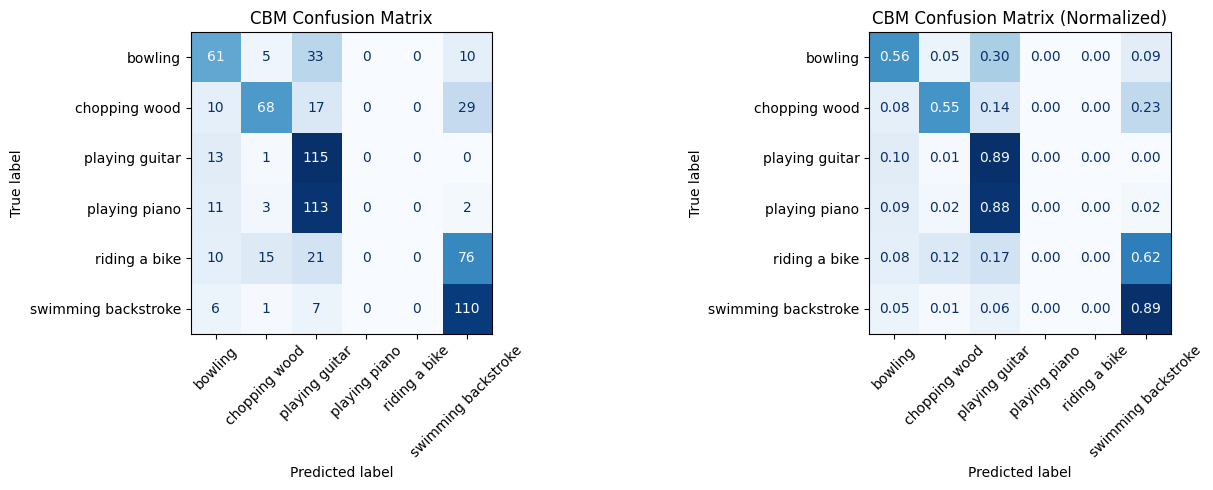

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=subset_class_names)
disp.plot(ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
axes[0].set_title("CBM Confusion Matrix")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=subset_class_names)
disp_norm.plot(ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=False, values_format=".2f")
axes[1].set_title("CBM Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()
